<a href="https://colab.research.google.com/github/mvgolubev99/kaggle-chemical-structure-and-logp/blob/dev/interaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# run these cells in google colab

In [ ]:
# clone repo
!git clone https://github.com/mvgolubev99/kaggle-chemical-structure-and-logp.git

In [21]:
# cd to project directory
!pwd
%cd /content/kaggle-chemical-structure-and-logp/
!pwd
!ls

/content/kaggle-chemical-structure-and-logp
/content/kaggle-chemical-structure-and-logp
README.md


In [42]:
# checkout to branch if neccesary
!git checkout dev

A	configs/default_lgbm_all_fingerprints.yaml
A	configs/default_ridge_all_fingerprints.yaml
Already on 'dev'
Your branch is up to date with 'origin/dev'.


In [23]:
# install packages
!pip install rdkit optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 36.2 MB/s eta 0:00:00


# Interaction

In [27]:
# download data
!mkdir -p ./data; curl -L -o ./data/archive_logp.zip https://www.kaggle.com/api/v1/datasets/download/matthewmasters/chemical-structure-and-logp; unzip ./data/archive_logp.zip -d ./data/; rm ./data/archive_logp.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 81468  100 81468    0     0   134k      0 --:--:-- --:--:-- --:--:--  134k
Archive:  ./data/archive_logp.zip
  inflating: ./data/logP_dataset.csv  


In [29]:
# generate fingerprints
!python fingerprints.py

Converting data from smiles to all fingerprints...

saving fingerprints to folder: 'data'

[1/7]
fp_name=MorganFingerprint_2048 
fingerprints saved as 'data/MorganFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[2/7]
fp_name=FeaturesMorganFingerprint_2048 
fingerprints saved as 'data/FeaturesMorganFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[3/7]
fp_name=MACCSKeysFingerprint_167 
fingerprints saved as 'data/MACCSKeysFingerprint_167_X_data.npy'
fps.shape=(14610, 167)
[4/7]
fp_name=RDKitFingerprint_2048 
fingerprints saved as 'data/RDKitFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[5/7]
fp_name=AtomPairFingerprint_2048 
fingerprints saved as 'data/AtomPairFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[6/7]
fp_name=TopologicalTorsionFingerprint_2048 
fingerprints saved as 'data/TopologicalTorsionFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[7/7]
fp_name=AvalonFingerprint_1024 
fingerprints saved as 'data/AvalonFingerprint_1024_X_data.npy'
fps.shape=(14

In [67]:
# FIX SEED!
from utils import set_seed
set_seed(42)

In [68]:
#!rm -rf ./results

In [109]:
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from search_cv import run_experiment_search_cv

[I 2025-11-16 17:35:44,832] A new study created in memory with name: dummy_experiment


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2025-11-16 17:35:45,605] Trial 0 finished with value: 1.4866779368653253 and parameters: {'regressor__model__strategy': 'constant', 'regressor__model__constant': 0.5447326914943933}. Best is trial 0 with value: 1.4866779368653253.
[I 2025-11-16 17:35:46,257] Trial 1 finished with value: 2.693950839718074 and parameters: {'regressor__model__strategy': 'constant', 'regressor__model__constant': 1.8051802745565158}. Best is trial 0 with value: 1.4866779368653253.
best_on_val_bootstrap_score {'metric_name': 'root_mean_squared_error', 'score_mean': 1.4781175965070028, 'score_CI': [1.4416769624196217, 1.5145185401718744]}


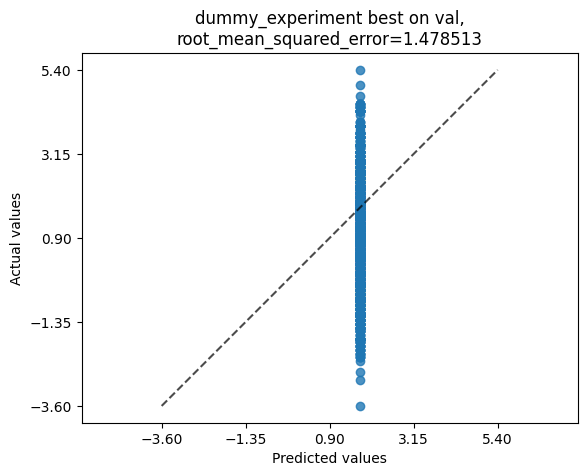

In [70]:
# random search with different constants on dummy classifier for testing
exp = run_experiment_search_cv("./configs/dummy_config.yaml")

[I 2025-11-16 17:35:57,945] A new study created in memory with name: default_xgb_all_fingerprints
/usr/local/lib/python3.12/dist-packages/optuna/progress_bar.py:51: UserWarning: Progress bar won't be displayed because n_trials and timeout are None.
  warnings.warn("Progress bar won't be displayed because n_trials and timeout are None.")
[I 2025-11-16 17:36:08,059] Trial 0 finished with value: 0.346165581380614 and parameters: {'regressor__fp_transform__name': 'AvalonFingerprint_1024'}. Best is trial 0 with value: 0.346165581380614.
[I 2025-11-16 17:36:09,811] Trial 1 finished with value: 0.3170670159921186 and parameters: {'regressor__fp_transform__name': 'MACCSKeysFingerprint_167'}. Best is trial 1 with value: 0.3170670159921186.
[I 2025-11-16 17:36:25,942] Trial 2 finished with value: 0.7974092351788172 and parameters: {'regressor__fp_transform__name': 'FeaturesMorganFingerprint_2048'}. Best is trial 1 with value: 0.3170670159921186.
[I 2025-11-16 17:36:45,093] Trial 3 finished with 

best_on_val_bootstrap_score {'metric_name': 'root_mean_squared_error', 'score_mean': 0.3085315178960654, 'score_CI': [0.29411281123605715, 0.323193157279608]}


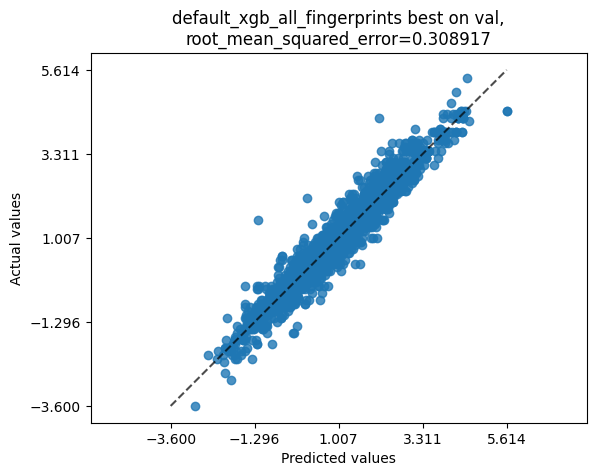

In [71]:
# grid search with ALL fingerprints on default xgbregressor
exp = run_experiment_search_cv("./configs/default_xgb_all_fingerprints.yaml")

[I 2025-11-16 17:37:47,924] A new study created in memory with name: default_lgbm_all_fingerprints
[I 2025-11-16 17:37:50,976] Trial 0 finished with value: 0.3480182167055582 and parameters: {'regressor__fp_transform__name': 'AvalonFingerprint_1024'}. Best is trial 0 with value: 0.3480182167055582.
[I 2025-11-16 17:37:52,112] Trial 1 finished with value: 0.3424944481879483 and parameters: {'regressor__fp_transform__name': 'MACCSKeysFingerprint_167'}. Best is trial 1 with value: 0.3424944481879483.
[I 2025-11-16 17:37:54,517] Trial 2 finished with value: 0.7995279853781863 and parameters: {'regressor__fp_transform__name': 'FeaturesMorganFingerprint_2048'}. Best is trial 1 with value: 0.3424944481879483.
[I 2025-11-16 17:38:01,839] Trial 3 finished with value: 0.43884741410548445 and parameters: {'regressor__fp_transform__name': 'RDKitFingerprint_2048'}. Best is trial 1 with value: 0.3424944481879483.
[I 2025-11-16 17:38:04,201] Trial 4 finished with value: 0.7995279853781863 and paramet

best_on_val_bootstrap_score {'metric_name': 'root_mean_squared_error', 'score_mean': 0.33507290680136453, 'score_CI': [0.32320486754344036, 0.3477127762420632]}


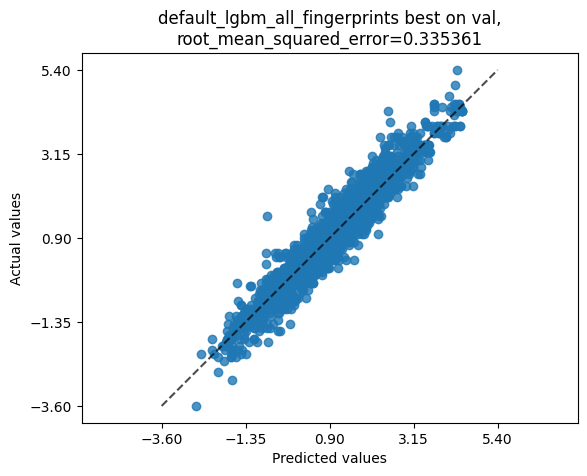

In [72]:
with warnings.catch_warnings():
    # lgbm creates column names for features
    # even though no arrays or dataframes are passed as arguments to .fit() method
    warnings.filterwarnings("ignore", category=UserWarning)

    # grid search with ALL fingerprints on default lgbm
    exp = run_experiment_search_cv("./configs/default_lgbm_all_fingerprints.yaml")

[I 2025-11-16 17:38:38,678] A new study created in memory with name: default_ridge_all_fingerprints
/usr/local/lib/python3.12/dist-packages/optuna/progress_bar.py:51: UserWarning: Progress bar won't be displayed because n_trials and timeout are None.
  warnings.warn("Progress bar won't be displayed because n_trials and timeout are None.")
[I 2025-11-16 17:38:41,293] Trial 0 finished with value: 0.47878251780669145 and parameters: {'regressor__fp_transform__name': 'AvalonFingerprint_1024'}. Best is trial 0 with value: 0.47878251780669145.
[I 2025-11-16 17:38:41,665] Trial 1 finished with value: 0.4595572113132854 and parameters: {'regressor__fp_transform__name': 'MACCSKeysFingerprint_167'}. Best is trial 1 with value: 0.4595572113132854.
[I 2025-11-16 17:38:50,716] Trial 2 finished with value: 0.8106112175924297 and parameters: {'regressor__fp_transform__name': 'FeaturesMorganFingerprint_2048'}. Best is trial 1 with value: 0.4595572113132854.
[I 2025-11-16 17:38:58,102] Trial 3 finished

best_on_val_bootstrap_score {'metric_name': 'root_mean_squared_error', 'score_mean': 0.4597499937786107, 'score_CI': [0.4417814679684518, 0.4767017714127563]}


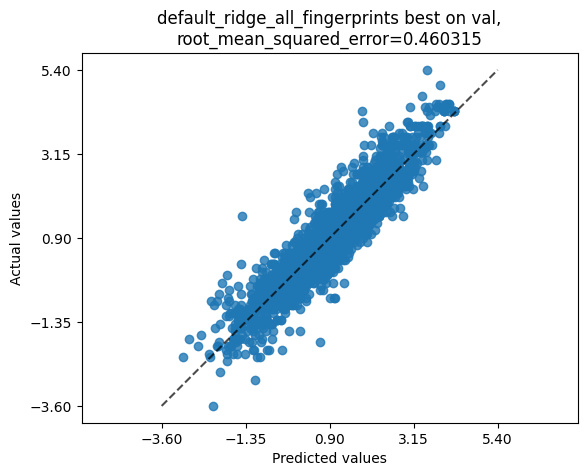

In [73]:
# grid search with ALL fingerprints on default ridge (linear regression with L2)
exp = run_experiment_search_cv("./configs/default_ridge_all_fingerprints.yaml")

[I 2025-11-16 17:39:25,967] A new study created in memory with name: default_mlpregressor_all_fingerprints
/usr/local/lib/python3.12/dist-packages/optuna/progress_bar.py:51: UserWarning: Progress bar won't be displayed because n_trials and timeout are None.
  warnings.warn("Progress bar won't be displayed because n_trials and timeout are None.")
[I 2025-11-16 17:40:37,252] Trial 0 finished with value: 0.2998434249367179 and parameters: {'regressor__fp_transform__name': 'AvalonFingerprint_1024'}. Best is trial 0 with value: 0.2998434249367179.
[I 2025-11-16 17:41:14,056] Trial 1 finished with value: 0.30725229600645765 and parameters: {'regressor__fp_transform__name': 'MACCSKeysFingerprint_167'}. Best is trial 0 with value: 0.2998434249367179.
[I 2025-11-16 17:44:38,552] Trial 2 finished with value: 0.8327169695665446 and parameters: {'regressor__fp_transform__name': 'FeaturesMorganFingerprint_2048'}. Best is trial 0 with value: 0.2998434249367179.
[I 2025-11-16 17:46:12,340] Trial 3 fi

best_on_val_bootstrap_score {'metric_name': 'root_mean_squared_error', 'score_mean': 0.28703889130671245, 'score_CI': [0.2711614427856121, 0.30352161110715853]}


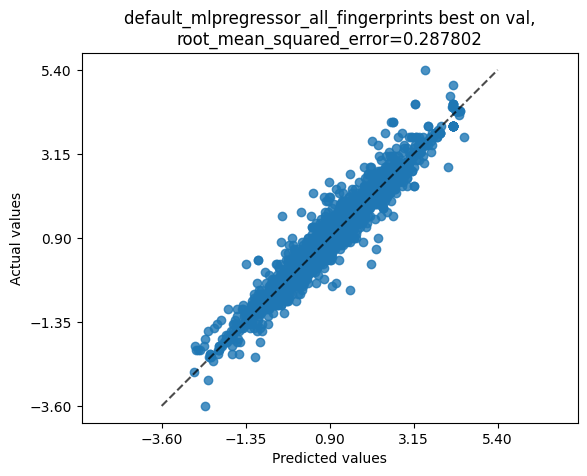

In [74]:
# grid search with ALL fingerprints on default MLPRegressor
exp = run_experiment_search_cv("./configs/default_mlpregressor_all_fingerprints.yaml")

In [79]:
# lets collect results

results_dflt_models = []
for f in Path("./results/").glob("default_*/*all_results.csv"):
    df = pd.read_csv(f)
    df['model'] = f.stem.replace("_all_fingerprints_grid_search_cv_all_results", "")
    results_dflt_models.append(df.sort_values("value"))

results_dflt_models = pd.concat(results_dflt_models, ignore_index=True)
results_dflt_models

,regressor__fp_transform__name,value,model
0,AvalonFingerprint_1024,0.299843,default_mlpregressor
1,MACCSKeysFingerprint_167,0.307252,default_mlpregressor
2,AtomPairFingerprint_2048,0.351693,default_mlpregressor
3,RDKitFingerprint_2048,0.379428,default_mlpregressor
4,FeaturesMorganFingerprint_2048,0.832717,default_mlpregressor
5,MorganFingerprint_2048,0.832717,default_mlpregressor
6,TopologicalTorsionFingerprint_2048,0.936663,default_mlpregressor
7,MACCSKeysFingerprint_167,0.459557,default_ridge
8,AvalonFingerprint_1024,0.478783,default_ridge
9,AtomPairFingerprint_2048,0.506885,default_ridge


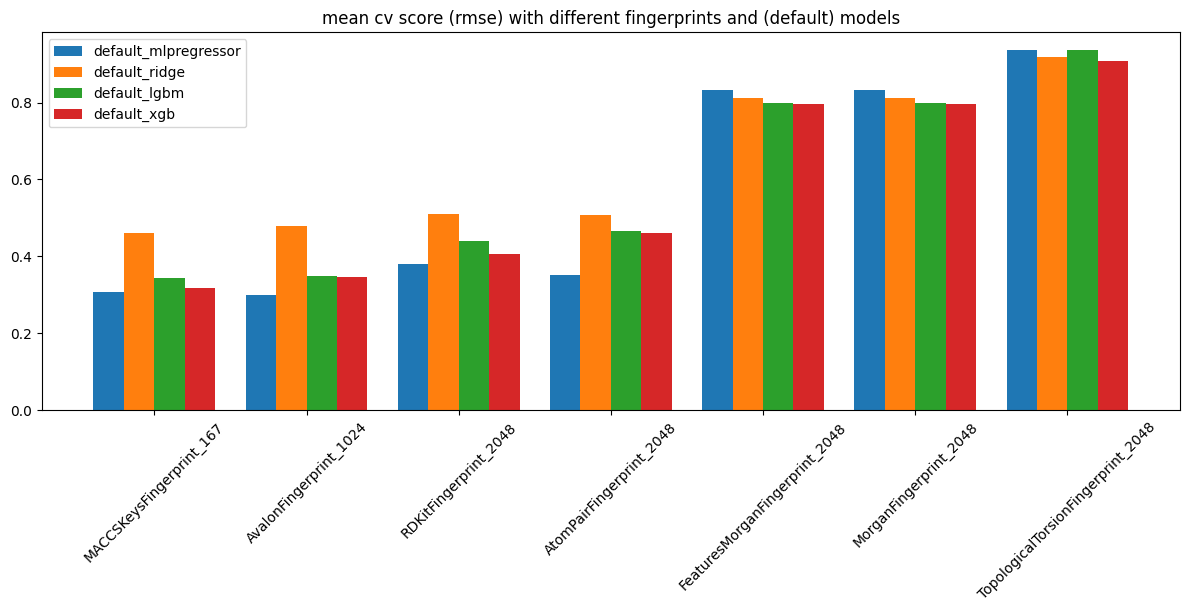

In [113]:
# collect all data
all_data = []
files = list(Path("./results/").glob("default_*/*all_results.csv"))

for f in files:
    df = pd.read_csv(f)
    df['model'] = f.parent.name.replace("_all_fingerprints", "")
    all_data.append(df)

# concat all data
combined_df = pd.concat(all_data)

# calculate mean for every fingerprint and sort
fingerprint_means = combined_df.groupby('regressor__fp_transform__name')['value'].mean().sort_values()
sorted_fingerprints = fingerprint_means.index.tolist()

# create graph
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(sorted_fingerprints))
width = 0.8 / len(files)

for i, f in enumerate(files):
    df = pd.read_csv(f)
    df = df.set_index('regressor__fp_transform__name').loc[sorted_fingerprints].reset_index()
    plt.bar(x_pos + i * width, df.value, width=width,
            label=f.parent.name.replace("_all_fingerprints", ""))

plt.xticks(x_pos + width * (len(files)-1)/2, sorted_fingerprints, rotation=45)
plt.legend()
plt.tight_layout()
plt.title("mean cv score (rmse) with different fingerprints and (default) models")
plt.show()

 We can see that FeaturesMorganFingerprint_2048, MorganFingerprint_2048 and TopologicalTorsionFingerprint_2048 have significantly higher rmse on cross-validation (at least without fine hyperparameter tuning of each model).

 MACCSKeys fingerprint seem to be better choice for tree-based models not only because of lowest error, but also due to interpretability of every bit.